# **Cellule 1 — Imports**

In [2]:
import os
import re
import math
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# **Cellule 2 — Seed + device**

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


# **Cellule 3 — Petit corpus texte**

In [4]:
text_corpus = """
je suis etudiant a emsi casablanca
j aime le deep learning
le deep learning permet de modeliser des sequences
les reseaux recurrentiels traitent les donnees sequentielles
un rnn simple peut avoir des difficultes de memorisation
les lstm et gru ameliorent la gestion du contexte
la perplexite permet d evaluer un modele de langage
le gradient clipping stabilise l entrainement
un sequence to sequence utilise un encodeur et un decodeur
le teacher forcing aide a accelerer l apprentissage
je travaille sur un projet de deep learning
ce projet contient mlp cnn et rnn
les images sont traitees par des cnn
les textes sont traites par des rnn lstm et gru
je veux comparer plusieurs architectures
""".lower()

text_corpus = re.sub(r"[^a-zA-Zàâçéèêëîïôûùüÿñæœ\s]", "", text_corpus)
text_corpus = re.sub(r"\s+", " ", text_corpus).strip()

print(text_corpus[:500])

je suis etudiant a emsi casablanca j aime le deep learning le deep learning permet de modeliser des sequences les reseaux recurrentiels traitent les donnees sequentielles un rnn simple peut avoir des difficultes de memorisation les lstm et gru ameliorent la gestion du contexte la perplexite permet d evaluer un modele de langage le gradient clipping stabilise l entrainement un sequence to sequence utilise un encodeur et un decodeur le teacher forcing aide a accelerer l apprentissage je travaille 


# **Cellule 4 — Tokenisation + vocabulaire**

In [5]:
tokens = text_corpus.split()

SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]
vocab = SPECIAL_TOKENS + sorted(list(set(tokens)))

stoi = {word: i for i, word in enumerate(vocab)}
itos = {i: word for word, i in stoi.items()}

pad_idx = stoi["<PAD>"]
unk_idx = stoi["<UNK>"]
sos_idx = stoi["<SOS>"]
eos_idx = stoi["<EOS>"]

encoded_tokens = [stoi.get(tok, unk_idx) for tok in tokens]

print("Taille vocabulaire :", len(vocab))
print("Exemple vocabulaire :", vocab[:20])
print("Encoded tokens :", encoded_tokens[:20])

Taille vocabulaire : 78
Exemple vocabulaire : ['<PAD>', '<UNK>', '<SOS>', '<EOS>', 'a', 'accelerer', 'aide', 'aime', 'ameliorent', 'apprentissage', 'architectures', 'avoir', 'casablanca', 'ce', 'clipping', 'cnn', 'comparer', 'contexte', 'contient', 'd']
Encoded tokens : [39, 66, 31, 4, 27, 12, 38, 7, 43, 22, 44, 43, 22, 44, 52, 20, 50, 23, 61, 45]


# **Cellule 5 — Création des séquences pour prédiction du prochain token**

In [6]:
seq_len = 5

inputs = []
targets = []

for i in range(len(encoded_tokens) - seq_len):
    inputs.append(encoded_tokens[i:i+seq_len])
    targets.append(encoded_tokens[i+1:i+seq_len+1])

inputs = np.array(inputs)
targets = np.array(targets)

print("Shape inputs :", inputs.shape)
print("Shape targets:", targets.shape)

Shape inputs : (109, 5)
Shape targets: (109, 5)


# **Cellule 6 — Split train / val / test**

In [7]:
n = len(inputs)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train, y_train = inputs[:train_end], targets[:train_end]
X_val, y_val = inputs[train_end:val_end], targets[train_end:val_end]
X_test, y_test = inputs[val_end:], targets[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (76, 5) (76, 5)
Val  : (16, 5) (16, 5)
Test : (17, 5) (17, 5)


# **Cellule 7 — Dataset PyTorch**

In [8]:
class LanguageModelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = LanguageModelDataset(X_train, y_train)
val_dataset = LanguageModelDataset(X_val, y_val)
test_dataset = LanguageModelDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
from torch.utils.data import DataLoader

# Ré-initialisation explicite des DataLoaders pour s'assurer qu'ils sont en mémoire
train_dataset = LanguageModelDataset(X_train, y_train)
val_dataset = LanguageModelDataset(X_val, y_val)
test_dataset = LanguageModelDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("DataLoaders initialisés avec succès.")

DataLoaders initialisés avec succès.


# **Cellule 8 — Modèle générique RNN / LSTM / GRU**

In [10]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, model_type="RNN", num_layers=1):
        super(LanguageModel, self).__init__()

        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if model_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        elif model_type == "GRU":
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        else:
            raise ValueError("model_type doit être RNN, LSTM ou GRU")

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        output, hidden = self.rnn(x)
        logits = self.fc(output)
        return logits

# **Cellule 9 — Perplexité**

In [11]:
def compute_perplexity(loss_value):
    return math.exp(loss_value)

# **Cellule 10 — Évaluation**

In [12]:
def evaluate_language_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))
            total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    ppl = compute_perplexity(avg_loss)
    return avg_loss, ppl

# **Cellule 11 — Entraînement avec gradient clipping**

In [13]:
def train_language_model(model, train_loader, val_loader, device, epochs=30, lr=0.001, clip_value=1.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_ppl": [],
        "val_ppl": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits.view(-1, logits.size(-1)), y_batch.view(-1))
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_value)
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)
        train_ppl = compute_perplexity(train_loss)

        val_loss, val_ppl = evaluate_language_model(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_ppl"].append(train_ppl)
        history["val_ppl"].append(val_ppl)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | Train PPL: {train_ppl:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val PPL: {val_ppl:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history

# **Cellule 12 — Lancer RNN, LSTM et GRU**

In [14]:
configs = ["RNN", "LSTM", "GRU"]
results = {}

for model_type in configs:
    print("\n==============================")
    print("Modèle :", model_type)
    print("==============================")

    model = LanguageModel(
        vocab_size=len(vocab),
        embed_dim=64,
        hidden_dim=128,
        model_type=model_type
    )

    trained_model, history = train_language_model(
        model, train_loader, val_loader, device,
        epochs=25, lr=0.001, clip_value=1.0
    )

    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    test_loss, test_ppl = evaluate_language_model(trained_model, test_loader, criterion, device)

    results[model_type] = {
        "model": trained_model,
        "history": history,
        "test_loss": test_loss,
        "test_ppl": test_ppl
    }

    print(f"Test Loss: {test_loss:.4f} | Test PPL: {test_ppl:.4f}")


Modèle : RNN
Epoch [1/25] | Train Loss: 4.2630 | Train PPL: 71.0261 | Val Loss: 4.3951 | Val PPL: 81.0561
Epoch [2/25] | Train Loss: 3.8920 | Train PPL: 49.0073 | Val Loss: 4.3757 | Val PPL: 79.4971
Epoch [3/25] | Train Loss: 3.5540 | Train PPL: 34.9516 | Val Loss: 4.3621 | Val PPL: 78.4246
Epoch [4/25] | Train Loss: 3.2142 | Train PPL: 24.8845 | Val Loss: 4.3549 | Val PPL: 77.8623
Epoch [5/25] | Train Loss: 2.8749 | Train PPL: 17.7231 | Val Loss: 4.3515 | Val PPL: 77.5984
Epoch [6/25] | Train Loss: 2.5416 | Train PPL: 12.6997 | Val Loss: 4.3545 | Val PPL: 77.8275
Epoch [7/25] | Train Loss: 2.2174 | Train PPL: 9.1838 | Val Loss: 4.3722 | Val PPL: 79.2178
Epoch [8/25] | Train Loss: 1.9099 | Train PPL: 6.7521 | Val Loss: 4.3953 | Val PPL: 81.0727
Epoch [9/25] | Train Loss: 1.6274 | Train PPL: 5.0908 | Val Loss: 4.4207 | Val PPL: 83.1537
Epoch [10/25] | Train Loss: 1.3712 | Train PPL: 3.9401 | Val Loss: 4.4474 | Val PPL: 85.4058
Epoch [11/25] | Train Loss: 1.1599 | Train PPL: 3.1895 | Va

# **Cellule 13 — Tableau comparatif**

In [15]:
comparison_df = pd.DataFrame([
    {
        "model": model_type,
        "test_loss": results[model_type]["test_loss"],
        "test_perplexity": results[model_type]["test_ppl"]
    }
    for model_type in results
]).sort_values(by="test_perplexity")

display(comparison_df)

,model,test_loss,test_perplexity
0,RNN,4.370008,79.044301
2,GRU,4.395851,81.113621
1,LSTM,4.396695,81.182090


# **Cellule 14 — Courbes d’apprentissage**

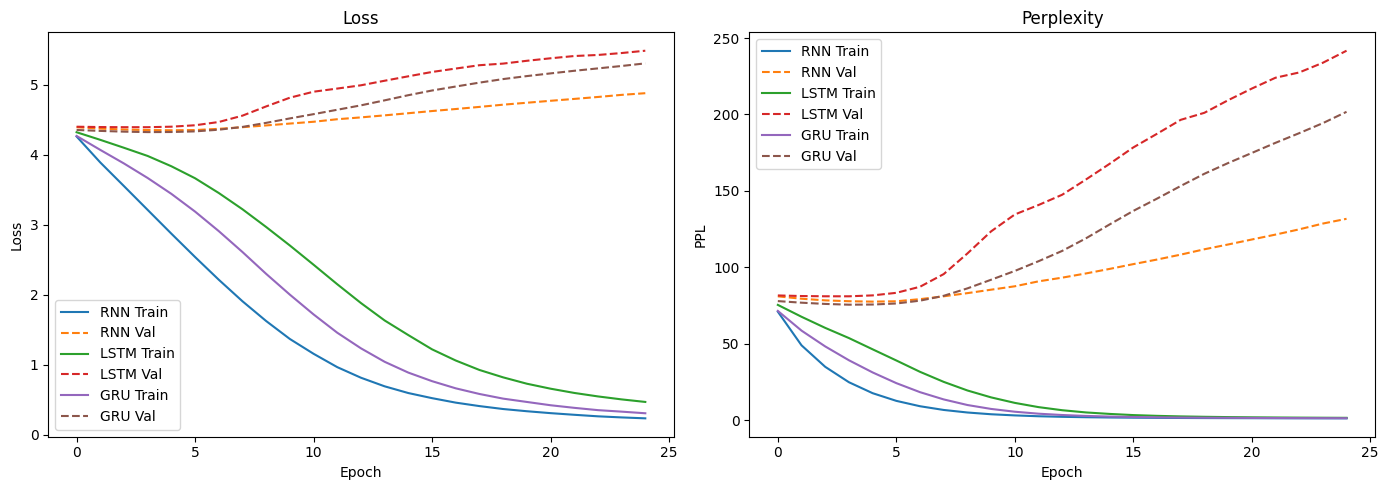

In [16]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for model_type in results:
    plt.plot(results[model_type]["history"]["train_loss"], label=f"{model_type} Train")
    plt.plot(results[model_type]["history"]["val_loss"], linestyle="--", label=f"{model_type} Val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for model_type in results:
    plt.plot(results[model_type]["history"]["train_ppl"], label=f"{model_type} Train")
    plt.plot(results[model_type]["history"]["val_ppl"], linestyle="--", label=f"{model_type} Val")
plt.title("Perplexity")
plt.xlabel("Epoch")
plt.ylabel("PPL")
plt.legend()

plt.tight_layout()
plt.show()

# **Cellule 15 — Génération simple de texte**

In [17]:
def generate_text(model, start_text, max_new_tokens=10):
    model.eval()
    words = start_text.lower().split()
    input_ids = [stoi.get(w, unk_idx) for w in words]

    for _ in range(max_new_tokens):
        x = torch.tensor([input_ids[-seq_len:]], dtype=torch.long).to(device)

        if x.size(1) < seq_len:
            pad_needed = seq_len - x.size(1)
            x = torch.cat([torch.full((1, pad_needed), pad_idx, dtype=torch.long).to(device), x], dim=1)

        with torch.no_grad():
            logits = model(x)
            next_token_logits = logits[0, -1]
            next_token = torch.argmax(next_token_logits).item()

        input_ids.append(next_token)

    generated_words = [itos[idx] for idx in input_ids]
    return " ".join(generated_words)

for model_type in results:
    print(f"\n--- {model_type} ---")
    print(generate_text(results[model_type]["model"], "je suis", max_new_tokens=8))


--- RNN ---
je suis les reseaux recurrentiels traitent les donnees sequentielles un

--- LSTM ---
je suis un sequence to sequence sequence utilise sequence utilise

--- GRU ---
je suis un decodeur le deep learning permet de modeliser


# **Cellule 16 — Petit corpus de traduction jouet**

In [18]:
pairs = [
    ("bonjour", "hello"),
    ("salut", "hi"),
    ("je suis etudiant", "i am student"),
    ("je travaille", "i work"),
    ("j aime le deep learning", "i like deep learning"),
    ("le modele apprend", "the model learns"),
    ("le reseau memorise", "the network memorizes"),
    ("bonsoir", "good evening"),
    ("merci", "thank you"),
    ("a bientot", "see you soon")
]

# **Cellule 17 — Vocabulaire source / cible**

In [19]:
def tokenize_sentence(sentence):
    return sentence.lower().split()

src_tokens = set()
tgt_tokens = set()

for src, tgt in pairs:
    src_tokens.update(tokenize_sentence(src))
    tgt_tokens.update(tokenize_sentence(tgt))

src_vocab = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"] + sorted(list(src_tokens))
tgt_vocab = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"] + sorted(list(tgt_tokens))

src_stoi = {w: i for i, w in enumerate(src_vocab)}
src_itos = {i: w for w, i in src_stoi.items()}

tgt_stoi = {w: i for i, w in enumerate(tgt_vocab)}
tgt_itos = {i: w for w, i in tgt_stoi.items()}

src_pad_idx = src_stoi["<PAD>"]
src_sos_idx = src_stoi["<SOS>"]
src_eos_idx = src_stoi["<EOS>"]

tgt_pad_idx = tgt_stoi["<PAD>"]
tgt_sos_idx = tgt_stoi["<SOS>"]
tgt_eos_idx = tgt_stoi["<EOS>"]

# **Cellule 18 — Encodage des phrases + padding**

In [20]:
def encode_sentence(sentence, stoi, add_sos=False, add_eos=True):
    tokens = tokenize_sentence(sentence)
    ids = [stoi.get(tok, stoi["<UNK>"]) for tok in tokens]
    if add_sos:
        ids = [stoi["<SOS>"]] + ids
    if add_eos:
        ids = ids + [stoi["<EOS>"]]
    return ids

encoded_pairs = []
for src, tgt in pairs:
    src_ids = encode_sentence(src, src_stoi, add_sos=False, add_eos=True)
    tgt_ids = encode_sentence(tgt, tgt_stoi, add_sos=True, add_eos=True)
    encoded_pairs.append((src_ids, tgt_ids))

max_src_len = max(len(src) for src, _ in encoded_pairs)
max_tgt_len = max(len(tgt) for _, tgt in encoded_pairs)

def pad_sequence(seq, max_len, pad_idx):
    return seq + [pad_idx] * (max_len - len(seq))

src_data = [pad_sequence(src, max_src_len, src_pad_idx) for src, _ in encoded_pairs]
tgt_data = [pad_sequence(tgt, max_tgt_len, tgt_pad_idx) for _, tgt in encoded_pairs]

src_tensor = torch.tensor(src_data, dtype=torch.long)
tgt_tensor = torch.tensor(tgt_data, dtype=torch.long)

print("Source shape:", src_tensor.shape)
print("Target shape:", tgt_tensor.shape)

Source shape: torch.Size([10, 6])
Target shape: torch.Size([10, 6])


# **Cellule 19 — Dataset Seq2Seq**

In [21]:
class Seq2SeqDataset(Dataset):
    def __init__(self, src_tensor, tgt_tensor):
        self.src = src_tensor
        self.tgt = tgt_tensor

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]

seq2seq_dataset = Seq2SeqDataset(src_tensor, tgt_tensor)
seq2seq_loader = DataLoader(seq2seq_dataset, batch_size=2, shuffle=True)

# **Cellule 20 — Encodeur**

In [22]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=src_pad_idx)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden

# **Cellule 21 — Décodeur**

In [23]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=tgt_pad_idx)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):
        input_token = input_token.unsqueeze(1)
        embedded = self.embedding(input_token)
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

# **Cellule 22 — Modèle Seq2Seq**

In [24]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        hidden = self.encoder(src)
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = output

            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

# **Cellule 23 — Entraînement Seq2Seq**

In [25]:
encoder = Encoder(len(src_vocab), emb_dim=32, hidden_dim=64)
decoder = Decoder(len(tgt_vocab), emb_dim=32, hidden_dim=64)
seq2seq_model = Seq2Seq(encoder, decoder, device).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tgt_pad_idx)
optimizer = torch.optim.Adam(seq2seq_model.parameters(), lr=0.01)

seq2seq_losses = []

for epoch in range(100):
    seq2seq_model.train()
    epoch_loss = 0

    for src_batch, tgt_batch in seq2seq_loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer.zero_grad()
        output = seq2seq_model(src_batch, tgt_batch, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        loss = criterion(output[:, 1:, :].reshape(-1, output_dim), tgt_batch[:, 1:].reshape(-1))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(seq2seq_model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(seq2seq_loader)
    seq2seq_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100] | Loss: {avg_loss:.4f}")

Epoch [10/100] | Loss: 0.4153
Epoch [20/100] | Loss: 0.0149
Epoch [30/100] | Loss: 0.0064
Epoch [40/100] | Loss: 0.0040
Epoch [50/100] | Loss: 0.0029
Epoch [60/100] | Loss: 0.0022
Epoch [70/100] | Loss: 0.0017
Epoch [80/100] | Loss: 0.0014
Epoch [90/100] | Loss: 0.0011
Epoch [100/100] | Loss: 0.0010


# **Cellule 24 — Courbe Seq2Seq**

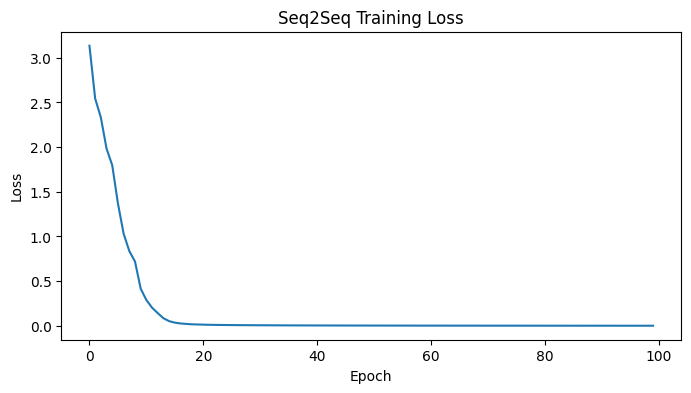

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(seq2seq_losses)
plt.title("Seq2Seq Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# **Cellule 25 — Décodage glouton**

In [27]:
def greedy_decode(model, sentence, max_len=10):
    model.eval()

    src_ids = encode_sentence(sentence, src_stoi, add_sos=False, add_eos=True)
    src_ids = pad_sequence(src_ids, max_src_len, src_pad_idx)
    src_tensor_input = torch.tensor([src_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor_input)

    input_token = torch.tensor([tgt_sos_idx], dtype=torch.long).to(device)
    generated_tokens = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden = model.decoder(input_token, hidden)

        top1 = output.argmax(1).item()
        if top1 == tgt_eos_idx:
            break

        generated_tokens.append(top1)
        input_token = torch.tensor([top1], dtype=torch.long).to(device)

    return " ".join([tgt_itos[idx] for idx in generated_tokens])

print(greedy_decode(seq2seq_model, "bonjour"))
print(greedy_decode(seq2seq_model, "je travaille"))

hello
i work


# **Cellule 26 — Beam search simplifié**

In [28]:
def beam_search_decode(model, sentence, beam_width=2, max_len=10):
    model.eval()

    src_ids = encode_sentence(sentence, src_stoi, add_sos=False, add_eos=True)
    src_ids = pad_sequence(src_ids, max_src_len, src_pad_idx)
    src_tensor_input = torch.tensor([src_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        hidden = model.encoder(src_tensor_input)

    beams = [([tgt_sos_idx], 0.0, hidden)]

    for _ in range(max_len):
        new_beams = []

        for seq, score, hidden_state in beams:
            input_token = torch.tensor([seq[-1]], dtype=torch.long).to(device)

            with torch.no_grad():
                output, new_hidden = model.decoder(input_token, hidden_state)
                log_probs = torch.log_softmax(output, dim=1)

            topk_log_probs, topk_indices = torch.topk(log_probs, beam_width)

            for k in range(beam_width):
                next_token = topk_indices[0, k].item()
                next_score = score + topk_log_probs[0, k].item()
                new_beams.append((seq + [next_token], next_score, new_hidden))

        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        if all(seq[-1] == tgt_eos_idx for seq, _, _ in beams):
            break

    best_seq = beams[0][0]

    decoded = []
    for idx in best_seq[1:]:
        if idx == tgt_eos_idx:
            break
        decoded.append(tgt_itos[idx])

    return " ".join(decoded)

print(beam_search_decode(seq2seq_model, "bonjour", beam_width=2))
print(beam_search_decode(seq2seq_model, "je travaille", beam_width=3))

hello
i work


# **Cellule 27 — Évaluation simple type BLEU simplifié**

In [29]:
def unigram_precision(reference, candidate):
    ref_tokens = reference.split()
    cand_tokens = candidate.split()

    if len(cand_tokens) == 0:
        return 0.0

    match_count = sum(1 for tok in cand_tokens if tok in ref_tokens)
    return match_count / len(cand_tokens)

references = []
predictions = []

for src, tgt in pairs:
    pred = greedy_decode(seq2seq_model, src)
    references.append(tgt)
    predictions.append(pred)

bleu_like_scores = [unigram_precision(ref, pred) for ref, pred in zip(references, predictions)]

eval_df = pd.DataFrame({
    "source": [p[0] for p in pairs],
    "reference": references,
    "prediction": predictions,
    "bleu_like": bleu_like_scores
})

display(eval_df)
print("Score moyen type BLEU simplifié :", np.mean(bleu_like_scores))

,source,reference,prediction,bleu_like
0,bonjour,hello,hello,1.0
1,salut,hi,hi,1.0
2,je suis etudiant,i am student,i am student,1.0
3,je travaille,i work,i work,1.0
4,j aime le deep learning,i like deep learning,i like deep learning,1.0
5,le modele apprend,the model learns,the model learns,1.0
6,le reseau memorise,the network memorizes,the network memorizes,1.0
7,bonsoir,good evening,good evening,1.0
8,merci,thank you,thank you,1.0
9,a bientot,see you soon,see you soon,1.0


Score moyen type BLEU simplifié : 1.0


# ***phase de test***

In [30]:
def predict_next_word(model, prefix, top_k=5):
    model.eval()
    words = prefix.lower().split()
    input_ids = [stoi.get(w, unk_idx) for w in words]

    # On prend les derniers tokens pour respecter la longueur seq_len
    x = torch.tensor([input_ids[-seq_len:]], dtype=torch.long).to(device)

    # Si la séquence est trop courte, on la pad à gauche
    if x.size(1) < seq_len:
        pad_needed = seq_len - x.size(1)
        x = torch.cat(
            [torch.full((1, pad_needed), pad_idx, dtype=torch.long).to(device), x],
            dim=1
        )

    with torch.no_grad():
        logits = model(x)          # [1, seq_len, vocab_size]
        last_logits = logits[0, -1]  # logits du dernier pas de temps
        probs = torch.softmax(last_logits, dim=0)

    top_probs, top_indices = torch.topk(probs, k=top_k)
    candidates = [(itos[idx.item()], top_probs[i].item()) for i, idx in enumerate(top_indices)]

    return candidates

In [31]:
test_prefixes = [
    "je suis",
    "j aime",
    "le deep",
    "les reseaux",
    "la perplexite"
]

for prefix in test_prefixes:
    print(f"\n=== Prefix: \"{prefix}\" ===")
    for model_type in ["RNN", "LSTM", "GRU"]:
        model = results[model_type]["model"]
        candidates = predict_next_word(model, prefix, top_k=5)
        print(f"{model_type}: ", ", ".join([f"{w} ({p:.3f})" for w, p in candidates]))


=== Prefix: "je suis" ===
RNN:  les (0.038), des (0.033), a (0.029), veux (0.021), suis (0.019)
LSTM:  un (0.017), traitent (0.017), la (0.016), casablanca (0.016), etudiant (0.015)
GRU:  un (0.026), modeliser (0.019), etudiant (0.018), stabilise (0.018), le (0.017)

=== Prefix: "j aime" ===
RNN:  le (0.075), apprentissage (0.027), gestion (0.021), des (0.020), les (0.020)
LSTM:  le (0.018), aime (0.018), deep (0.017), sequence (0.017), permet (0.017)
GRU:  le (0.022), un (0.021), de (0.020), les (0.018), deep (0.018)

=== Prefix: "le deep" ===
RNN:  learning (0.179), evaluer (0.028), l (0.023), clipping (0.022), forcing (0.020)
LSTM:  learning (0.035), deep (0.023), permet (0.022), l (0.018), difficultes (0.017)
GRU:  learning (0.044), deep (0.025), le (0.023), teacher (0.020), de (0.019)

=== Prefix: "les reseaux" ===
RNN:  recurrentiels (0.108), sequentielles (0.032), et (0.028), de (0.023), langage (0.023)
LSTM:  recurrentiels (0.018), deep (0.017), permet (0.017), simple (0.016),

In [32]:
def complete_sentence(model, start_text, max_new_tokens=8):
    model.eval()
    words = start_text.lower().split()
    input_ids = [stoi.get(w, unk_idx) for w in words]

    for _ in range(max_new_tokens):
        x = torch.tensor([input_ids[-seq_len:]], dtype=torch.long).to(device)

        if x.size(1) < seq_len:
            pad_needed = seq_len - x.size(1)
            x = torch.cat(
                [torch.full((1, pad_needed), pad_idx, dtype=torch.long).to(device), x],
                dim=1
            )

        with torch.no_grad():
            logits = model(x)
            next_logits = logits[0, -1]
            probs = torch.softmax(next_logits, dim=0)

            # On sample au lieu de prendre argmax pour avoir un peu de variété
            next_token = torch.multinomial(probs, num_samples=1).item()

        input_ids.append(next_token)

    return " ".join([itos[idx] for idx in input_ids])

In [33]:
start_sentences = [
    "je suis",
    "j aime le",
    "le deep learning",
    "les reseaux recurrentiels"
]

for sent in start_sentences:
    print(f"\n=== Phrase de départ: \"{sent}\" ===")
    for model_type in ["RNN", "LSTM", "GRU"]:
        model = results[model_type]["model"]
        generated = complete_sentence(model, sent, max_new_tokens=6)
        print(f"{model_type} -> {generated}")


=== Phrase de départ: "je suis" ===
RNN -> je suis emsi encodeur des avoir decodeur lstm
LSTM -> je suis gradient learning modeliser evaluer sequences projet
GRU -> je suis travaille plusieurs encodeur des et sequences

=== Phrase de départ: "j aime le" ===
RNN -> j aime le teacher suis le plusieurs mlp permet
LSTM -> j aime le accelerer d forcing permet emsi learning
GRU -> j aime le apprentissage <PAD> a <SOS> modeliser emsi

=== Phrase de départ: "le deep learning" ===
RNN -> le deep learning et teacher modeliser a un utilise
LSTM -> le deep learning <PAD> des contexte la forcing je
GRU -> le deep learning simple langage veux mlp suis stabilise

=== Phrase de départ: "les reseaux recurrentiels" ===
RNN -> les reseaux recurrentiels traitent permet emsi sequences evaluer sequences
LSTM -> les reseaux recurrentiels casablanca stabilise aime du reseaux l
GRU -> les reseaux recurrentiels projet je teacher sequence to learning


In [34]:
example_sentence = "je suis etudiant a emsi casablanca"
words = example_sentence.lower().split()
indices = [stoi.get(w, unk_idx) for w in words]

prefix = " ".join(words[:seq_len])  # les premiers mots
true_next = words[seq_len]          # mot suivant dans la phrase

print("Prefix :", prefix)
print("Vrai prochain mot :", true_next)

for model_type in ["RNN", "LSTM", "GRU"]:
    model = results[model_type]["model"]
    candidates = predict_next_word(model, prefix, top_k=5)
    print(f"{model_type}: ", ", ".join([f"{w} ({p:.3f})" for w, p in candidates]))

Prefix : je suis etudiant a emsi
Vrai prochain mot : casablanca
RNN:  casablanca (0.118), un (0.044), et (0.027), de (0.026), utilise (0.022)
LSTM:  casablanca (0.021), la (0.019), traitent (0.017), emsi (0.017), langage (0.016)
GRU:  casablanca (0.031), j (0.020), a (0.020), un (0.020), le (0.019)
